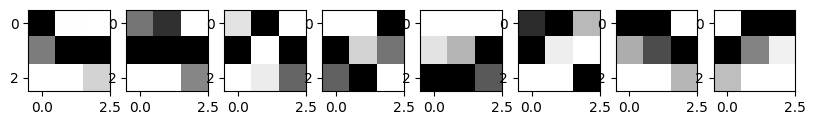

In [86]:
from keras.models import model_from_json
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from modules.setting import OUTPUT_PATH

# テストデータを読み込む
x_test = np.load(f"{OUTPUT_PATH}/x_test.npy")
y_test = np.load(f"{OUTPUT_PATH}/y_test.npy")

# 保存したファイルを読み込む
model = None
with open(f"{OUTPUT_PATH}/model.json") as f:
    model = model_from_json(f.read())
# モデルに学習済みの重みを与える
model.load_weights(f"{OUTPUT_PATH}/weight.hdf5")
# 最初の畳み込み層のフィルタの重みを読み込む（バイアスは含まない）
W = model.layers[0].get_weights()[0]
# 軸の順番を入れ替えて形状を（フィルタ，チャンネル，高さ，幅）に直す．
W = W.transpose(3, 2, 0, 1)
filter_num, channel_num, row_num, col_num = W.shape
# フィルタの重みをpyplotで可視化する．
plt.figure(figsize=(20, 20))
for i in range(filter_num):
    img = W[i, 0]  # i番目のフィルタ
    # 図示するためにスケーラーを使って0～255に収めて表示
    scaler = MinMaxScaler(feature_range=(0, 255))
    img = scaler.fit_transform(img)
    plt.subplot(int(filter_num / 2), 16, i + 1)
    plt.imshow(img, cmap="gray")
plt.show()

In [87]:
# 識別確率:
print(f"{'最終的なテストデータの正答率':#^30}")
model.compile(loss="categorical_crossentropy", optimizer="sgd", metrics=["acc"])
loss_and_metrics = model.evaluate(x_test, y_test)
print(list(zip(model.metrics_names, loss_and_metrics)))

########最終的なテストデータの正答率########
1/1 [==============================] - 0s 420ms/step - loss: 0.4897 - acc: 0.8125
[('loss', 0.4896794855594635), ('acc', 0.8125)]


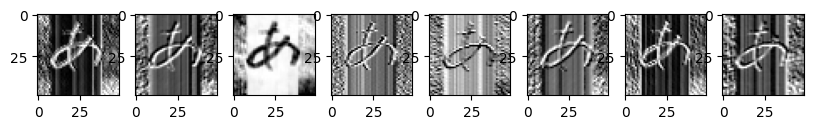

In [74]:
from keras import backend as K

layer_output = K.function([model.layers[0].input], [model.layers[0].output])
x_test_sample = x_test[6].reshape(1, x_test.shape[1], x_test.shape[2], 1)
feature_maps = layer_output(x_test_sample)[0]

plt.figure(figsize=(20, 20))
for i in range(feature_maps.shape[3]):
    out = feature_maps[:, :, :, i]
    out = out.reshape(out.shape[1], out.shape[2])
    scaler = MinMaxScaler(feature_range=(0, 255))
    out = scaler.fit_transform(out)
    plt.subplot(int(filter_num / 2), 16, i + 1)
    plt.imshow(out, cmap="gray")
plt.show()

1/1 [==============================] - 0s 42ms/step
##########入力された文字の確率##########

の:0.0000
あ:0.0000
ぬ:0.9996
め:0.0004

テストデータは3番目の文字「ぬ」である確率が高い


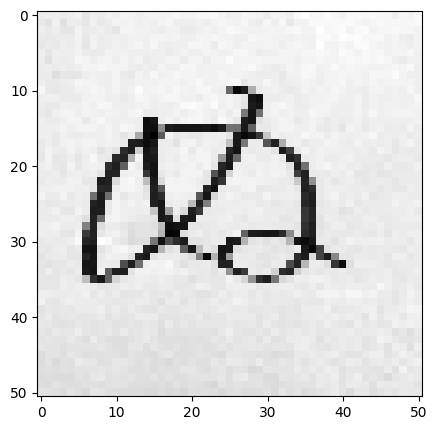

In [75]:
import random

# テストに使う画像
test_sample = random.randint(0, x_test.shape[0]-1)

# 識別
pred = model.predict(
    x_test[test_sample].reshape(1, x_test.shape[1], x_test.shape[2], 1), batch_size=1
)

##########変更箇所###########
# 各自の文字に合わせてラベルを変更する
labels = {0: "の", 1: "あ", 2: "ぬ", 3: "め"}
#############################
print(f"{'入力された文字の確率':#^30}\n")
for k, v in labels.items():
    print(f"{v}:{pred[-1][k]:.4f}")
print(f"\nテストデータは{np.argmax(pred[-1])+1}番目の文字「{labels[np.argmax(pred[-1])]}」である確率が高い")

# matplotlibでテスト画像を表示
x_test2 = x_test.reshape(-1, x_test.shape[1], x_test.shape[2])
plt.figure(figsize=(5, 5))
plt.imshow(x_test2[test_sample])
plt.gray()
plt.show()